# Problem 1 — Hierarchical Navigable Small World (HNSW)  &nbsp;&nbsp; 25 points

Given a randomly-generated dataset of vectors, implement and analyze the **Hierarchical Navigable Small World (HNSW)** algorithm from scratch.  
HNSW is the core indexing algorithm behind modern vector databases used in RAG systems (e.g., Chroma, Pinecone, Weaviate all use HNSW internally).

**Required Libraries:** `numpy`, `networkx`, `matplotlib`

---

## Test Parameters

Use **two separate parameter sets** for different parts of Task (c).

| | Visualization dataset | Performance dataset |
|---|---|---|
| **Purpose** | Graph plots & search-path visualization | Timing & accuracy benchmarks |
| **n_vectors** | 50 | 1000 |
| **dimension** | 2 | 16 |
| **m_neighbors** | 4 | 8 |
| **query** | `np.array([0.5, 0.5])` | `np.random.seed(42); query = np.random.rand(16)` |

> **Why two datasets?**  
> With *n=50, M=4, dim=2* the graph produces 2–3 layers that can be drawn clearly in 2-D.  
> With *n=1000, M=8, dim=16* the logarithmic speedup over brute force becomes clearly measurable (expected construction: 5–20 s on CPU; search is near-instantaneous).

---

## Algorithm Overview

HNSW builds a **multi-layer proximity graph**:

```
Layer 2 (top):   sparse long-range links  — few nodes
Layer 1 (mid):   medium-density links     — moderate nodes
Layer 0 (base):  dense short-range links  — ALL nodes
```

**Construction** — for each new vector `v`:
1. Sample its *maximum layer* `l_max` from a geometric/exponential distribution:  
   `l_max = floor(-ln(uniform(0,1)) * m_L)` where `m_L = 1/ln(M)`.
2. Add `v` to every layer from `0` up to `l_max`.
3. In each layer `≤ l_max`, connect `v` to its `M` nearest neighbors **already in that layer**.

**Search** — given a query `q`:
1. Start from the single *entry point* in the **top layer**.
2. Greedily move to whichever neighbor is closest to `q` (greedy best-first).
3. When no neighbor improves, **descend** to the next layer using the current node as the new entry point.
4. Repeat until Layer 0 is exhausted — return the closest node found.

---
## Setup

In [ ]:
# Import required libraries
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import time

# ── Visualization dataset ────────────────────────────────────────────────────
np.random.seed(0)              # reproducibility
N_VIZ        = 50
DIM_VIZ      = 2
M_VIZ        = 4
vectors_viz  = np.random.rand(N_VIZ, DIM_VIZ)
query_viz    = np.array([0.5, 0.5])

# ── Performance dataset ──────────────────────────────────────────────────────
np.random.seed(1)              # reproducibility
N_PERF       = 1000
DIM_PERF     = 16
M_PERF       = 8
vectors_perf = np.random.rand(N_PERF, DIM_PERF)
np.random.seed(42)
query_perf   = np.random.rand(DIM_PERF)

print("Visualization vectors shape :", vectors_viz.shape)
print("Performance  vectors shape  :", vectors_perf.shape)

Visualization vectors shape : (50, 2)
Performance  vectors shape  : (1000, 16)


---
## Task (a) — Construct HNSW &nbsp;&nbsp; (10 points)

Implement `construct_HNSW(vectors, m_neighbors)` that builds the hierarchical graph.

**Signature:**
```python
def construct_HNSW(vectors, m_neighbors):
    """
    Parameters
    ----------
    vectors     : np.ndarray, shape (n, d)
    m_neighbors : int  — max edges per node per layer

    Returns
    -------
    graph_layers : list[nx.Graph]  — index 0 = base layer, index -1 = top layer
                   Each node has attribute 'pos' storing its vector.
    """
```

**Implementation hints:**
- Compute the level multiplier: `m_L = 1.0 / np.log(m_neighbors)`
- For each vector, draw its max layer: `l_max = int(-np.log(np.random.uniform()) * m_L)`  
  Clip to a reasonable maximum (e.g. `min(l_max, 6)`) to avoid degenerate single-node layers.
- Pre-allocate the layer list; create a new `nx.Graph()` lazily when a layer is first needed.
- For efficiency, when searching for the `M` nearest neighbors within a layer, iterate only over nodes already added to that layer.
- Store each node's vector as a node attribute: `G.nodes[node_id]['pos'] = vector`
- The **entry point** for insertion in layers above `l_max` is the first node that appears in a layer (you can track this separately or use `list(G.nodes)[0]`).

In [ ]:
def construct_HNSW(vectors, m_neighbors):
    """
    Build an HNSW index from scratch.

    Parameters
    ----------
    vectors     : np.ndarray, shape (n, d)
    m_neighbors : int

    Returns
    -------
    graph_layers : list[nx.Graph]   (index 0 = base layer)
    """
    n, d = vectors.shape
    m_L = 1.0 / np.log(m_neighbors)
    graph_layers = []

    for i in range(n):
        v = vectors[i]
        l_max = int(-np.log(np.random.uniform()) * m_L)
        l_max = min(l_max, 6)

        # Create layers on demand
        while len(graph_layers) <= l_max:
            graph_layers.append(nx.Graph())

        for layer in range(l_max + 1):
            G = graph_layers[layer]
            G.add_node(i, pos=v.copy())

            nodes_in_layer = [nid for nid in G.nodes() if nid != i]
            if nodes_in_layer:
                positions = np.array([G.nodes[nid]['pos'] for nid in nodes_in_layer])
                dists = np.linalg.norm(positions - v, axis=1)
                k = min(m_neighbors, len(nodes_in_layer))
                idx = np.argsort(dists)[:k]
                for j in idx:
                    G.add_edge(i, nodes_in_layer[j])

    return graph_layers


# ── Build on the visualization dataset ──────────────────────────────────────
np.random.seed(0)
graph_layers_viz = construct_HNSW(vectors_viz, M_VIZ)

print(f"Number of layers built : {len(graph_layers_viz)}")
for i, G in enumerate(graph_layers_viz):
    print(f"  Layer {i}: {G.number_of_nodes():>4} nodes, {G.number_of_edges():>4} edges")

Number of layers built : 3
  Layer 0:   50 nodes,  190 edges
  Layer 1:    9 nodes,   26 edges
  Layer 2:    3 nodes,    3 edges


#### Visualize the layer-by-layer graph structure (visualization dataset)

Draw each layer as a 2-D scatter + edges using the `'pos'` node attribute.  
Use `nx.draw_networkx` with `pos = nx.get_node_attributes(G, 'pos')`.

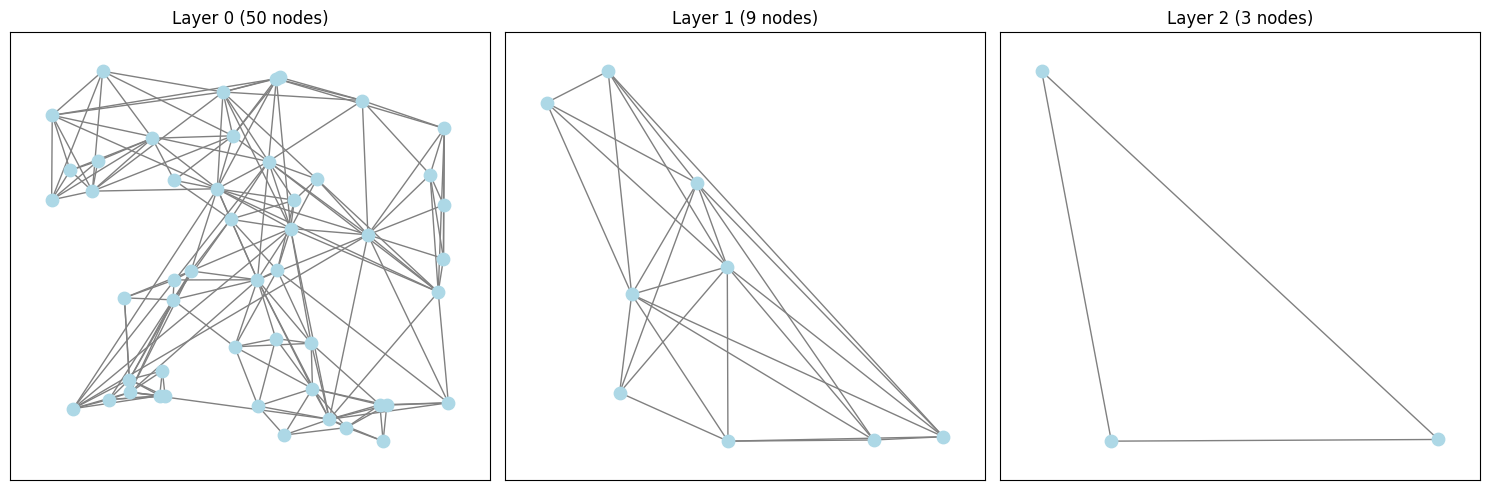

In [ ]:
# Visualize all layers of the HNSW graph
# Tip: subplot one axis per layer; title each subplot "Layer i (k nodes)"

# YOUR CODE HERE

n_layers = len(graph_layers_viz)
fig, axes = plt.subplots(1, n_layers, figsize=(5 * n_layers, 5))
if n_layers == 1:
    axes = [axes]
for i, G in enumerate(graph_layers_viz):
    pos_dict = nx.get_node_attributes(G, 'pos')
    ax = axes[i]
    nx.draw_networkx(G, pos=pos_dict, ax=ax, with_labels=False,
                     node_size=80, node_color='lightblue', edge_color='gray')
    ax.set_title(f"Layer {i} ({G.number_of_nodes()} nodes)")
plt.tight_layout()
plt.show()

---
## Task (b) — Search HNSW &nbsp;&nbsp; (8 points)

Implement `search_HNSW(graph_layers, query)` using the greedy layer-wise strategy.

**Signature:**
```python
def search_HNSW(graph_layers, query):
    """
    Parameters
    ----------
    graph_layers : list[nx.Graph]   output of construct_HNSW
    query        : np.ndarray, shape (d,)

    Returns
    -------
    nearest_node : int   — index of the approximate nearest neighbor
    search_path  : list[list[int]]  — path taken per layer (index 0 = top)
    """
```

**Algorithm (greedy best-first per layer):**
```
entry ← any node in the top layer   (e.g. list(graph_layers[-1].nodes)[0])

for layer in reversed(graph_layers):   # top → bottom
    if entry not in layer: continue    # node absent in this layer — skip
    path_for_this_layer = [entry]
    repeat:
        best_neighbor ← argmin dist(neighbor, query)  over neighbors of entry
        if dist(best_neighbor, query) < dist(entry, query):
            entry ← best_neighbor
            path_for_this_layer.append(entry)
        else:
            break   ← local minimum reached; descend to next layer

return entry, search_path
```

**Hint:** Use `np.linalg.norm(vectors[node] - query)` for Euclidean distance, or read the `'pos'` attribute from the graph node.

In [ ]:
def search_HNSW(graph_layers, query):
    """
    Approximate nearest neighbor search via greedy layer traversal.

    Parameters
    ----------
    graph_layers : list[nx.Graph]
    query        : np.ndarray

    Returns
    -------
    nearest_node : int
    search_path  : list[list[int]]   one sub-list per layer visited (top first)
    """
    if not graph_layers:
        return None, []

    top_layer = graph_layers[-1]
    entry = list(top_layer.nodes())[0]
    search_path = []

    for layer_idx in range(len(graph_layers) - 1, -1, -1):
        G = graph_layers[layer_idx]
        if entry not in G.nodes:
            continue
        path_for_this_layer = [entry]
        while True:
            entry_pos = G.nodes[entry]['pos']
            entry_dist = np.linalg.norm(entry_pos - query)
            neighbors = list(G.neighbors(entry))
            if not neighbors:
                break
            best_neighbor = None
            best_dist = np.inf
            for n in neighbors:
                n_pos = G.nodes[n]['pos']
                d = np.linalg.norm(n_pos - query)
                if d < best_dist:
                    best_dist = d
                    best_neighbor = n
            if best_neighbor is not None and best_dist < entry_dist:
                entry = best_neighbor
                path_for_this_layer.append(entry)
            else:
                break
        search_path.append(path_for_this_layer)

    return entry, search_path


# ── Test on the visualization dataset ───────────────────────────────────────
nearest_viz, path_viz = search_HNSW(graph_layers_viz, query_viz)

print(f"Query          : {query_viz}")
print(f"Nearest (HNSW) : node {nearest_viz}  →  {vectors_viz[nearest_viz]}")
print(f"Layers visited : {len(path_viz)}")
for i, layer_path in enumerate(path_viz):
    print(f"  Layer {i}: {layer_path}")

Query          : [0.5 0.5]
Nearest (HNSW) : node 16  →  [0.45615033 0.56843395]
Layers visited : 3
  Layer 0: [16]
  Layer 1: [16]
  Layer 2: [16]


---
## Task (c) — Evaluation &nbsp;&nbsp; (7 points)

This task has two parts:

| Sub-task | Dataset | What to do |
|---|---|---|
| **c-1** | Visualization | Visualize search path layer-by-layer |
| **c-2** | Performance | Timing + accuracy vs. brute force |

### c-1 — Visualize the search path (visualization dataset)

For each layer visited during the search, draw the graph and overlay the path taken:  
- Draw all nodes and edges in light gray.  
- Highlight path nodes in a distinct color (e.g. red) and connect them with arrows.  
- Mark the query point with a star (★).  
- Mark the final nearest neighbor found.

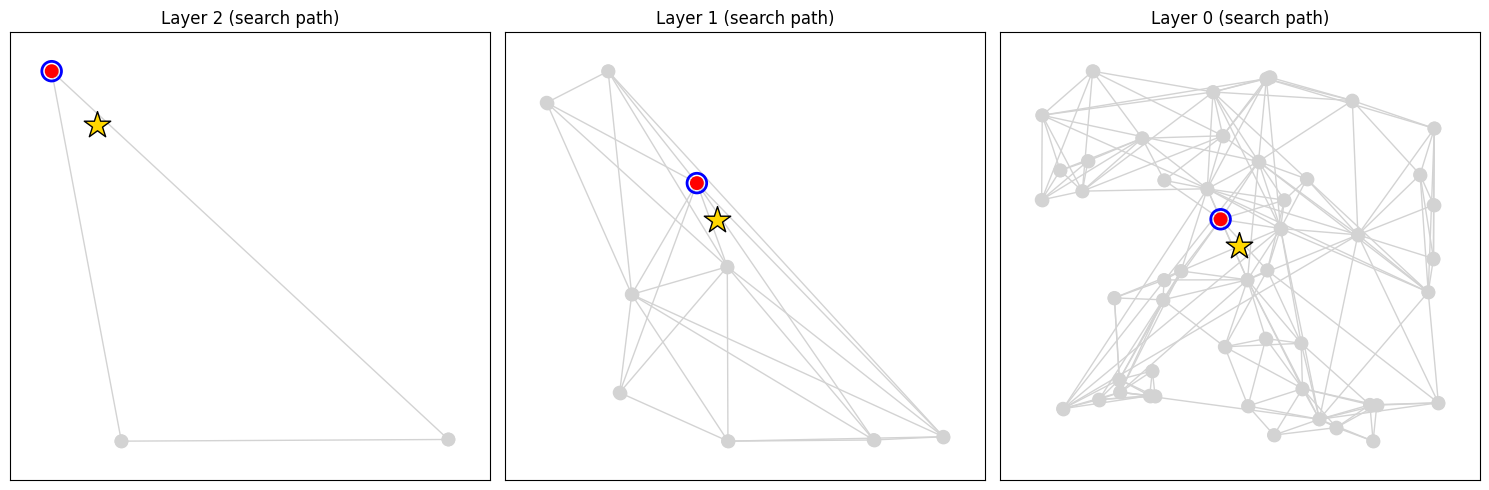

In [ ]:
# Visualize the search path on the visualization dataset
# Tip: iterate over path_viz; for each layer index, draw graph_layers_viz[layer_index]
#      then draw the path nodes on top.

n_layers = len(path_viz)
fig, axes = plt.subplots(1, n_layers, figsize=(5 * n_layers, 5))
if n_layers == 1:
    axes = [axes]
for i, layer_path in enumerate(path_viz):
    G = graph_layers_viz[len(graph_layers_viz) - 1 - i]
    pos_dict = nx.get_node_attributes(G, 'pos')
    ax = axes[i]
    nx.draw_networkx(G, pos=pos_dict, ax=ax, with_labels=False,
                     node_size=80, node_color='lightgray', edge_color='lightgray')
    # Highlight path nodes in red
    path_nodes = set(layer_path)
    path_colors = ['red' if n in path_nodes else 'lightgray' for n in G.nodes()]
    nx.draw_networkx_nodes(G, pos=pos_dict, nodelist=list(G.nodes()),
                           node_color=path_colors, ax=ax, node_size=80)
    # Draw path edges
    for j in range(len(layer_path) - 1):
        u, v = layer_path[j], layer_path[j + 1]
        if G.has_edge(u, v):
            nx.draw_networkx_edges(G, pos_dict, [(u, v)], ax=ax, edge_color='red', width=2)
    # Mark query with star
    ax.scatter(*query_viz, marker='*', s=400, c='gold', edgecolors='black', zorder=5)
    # Mark final nearest neighbor (overall answer)
    if nearest_viz in G.nodes:
        ax.scatter(*G.nodes[nearest_viz]['pos'], marker='o', s=200,
                   facecolors='none', edgecolors='blue', linewidths=2, zorder=5)
    ax.set_title(f"Layer {len(graph_layers_viz)-1-i} (search path)")
plt.tight_layout()
plt.show()

### c-2 — Timing & accuracy (performance dataset)

#### Step 1: Build HNSW on the performance dataset and time construction

In [ ]:
# Build HNSW on the performance dataset — measure construction time
np.random.seed(1)
t0 = time.perf_counter()
graph_layers_perf = construct_HNSW(vectors_perf, M_PERF)
t_construct_hnsw = time.perf_counter() - t0

print(f"HNSW construction time : {t_construct_hnsw:.3f} s")
print(f"Number of layers       : {len(graph_layers_perf)}")
for i, G in enumerate(graph_layers_perf):
    print(f"  Layer {i}: {G.number_of_nodes():>5} nodes, {G.number_of_edges():>5} edges")

HNSW construction time : 0.423 s
Number of layers       : 5
  Layer 0:  1000 nodes,  7964 edges
  Layer 1:   119 nodes,   916 edges
  Layer 2:    20 nodes,   124 edges
  Layer 3:     2 nodes,     1 edges
  Layer 4:     1 nodes,     0 edges


#### Step 2: Implement brute-force nearest neighbor search

In [ ]:
def brute_force_nn(vectors, query):
    """
    Exact nearest neighbor by exhaustive search.

    Parameters
    ----------
    vectors : np.ndarray, shape (n, d)
    query   : np.ndarray, shape (d,)

    Returns
    -------
    nearest_idx  : int
    nearest_dist : float
    """
    dists = np.linalg.norm(vectors - query, axis=1)
    nearest_idx = int(np.argmin(dists))
    nearest_dist = float(dists[nearest_idx])
    return nearest_idx, nearest_dist


# Time the brute-force construction (just building the index = nothing to build — it's O(1) setup)
# and query
t0 = time.perf_counter()
bf_idx, bf_dist = brute_force_nn(vectors_perf, query_perf)
t_search_bf = time.perf_counter() - t0

print(f"Brute-force result : node {bf_idx}  dist = {bf_dist:.6f}")
print(f"Brute-force search time : {t_search_bf*1000:.3f} ms")

Brute-force result : node 386  dist = 1.020759
Brute-force search time : 1.151 ms


#### Step 3: Run HNSW search and compare

In [ ]:
# Time HNSW search on the performance dataset
t0 = time.perf_counter()
nearest_perf, path_perf = search_HNSW(graph_layers_perf, query_perf)
t_search_hnsw = time.perf_counter() - t0

hnsw_dist = np.linalg.norm(vectors_perf[nearest_perf] - query_perf)

print(f"HNSW result        : node {nearest_perf}  dist = {hnsw_dist:.6f}")
print(f"HNSW search time   : {t_search_hnsw*1000:.3f} ms")
print()
print("── Summary ──────────────────────────────────────────")
print(f"  Brute-force distance : {bf_dist:.6f}")
print(f"  HNSW distance        : {hnsw_dist:.6f}")
print(f"  Exact match          : {nearest_perf == bf_idx}")
print(f"  Search speedup       : {t_search_bf / t_search_hnsw:.1f}×  (BF / HNSW)")

HNSW result        : node 386  dist = 1.020759
HNSW search time   : 2.630 ms

── Summary ──────────────────────────────────────────
  Brute-force distance : 1.020759
  HNSW distance        : 1.020759
  Exact match          : True
  Search speedup       : 0.4×  (BF / HNSW)


#### Step 4: Multi-query accuracy evaluation

Run both methods on **100 random queries** and report the fraction for which HNSW returns the exact nearest neighbor.

In [ ]:
# Evaluate HNSW accuracy over multiple queries
# Tip:
#   1. Generate 100 random query vectors of shape (DIM_PERF,)
#   2. For each query, get the brute-force exact answer and the HNSW answer
#   3. Accuracy = fraction of queries where HNSW returns the same node as brute force
#   4. Also report mean distance ratio: hnsw_dist / bf_dist (1.0 = perfect)

np.random.seed(99)
N_QUERIES = 100

exact_matches = 0
distance_ratios = []
for _ in range(N_QUERIES):
    q = np.random.rand(DIM_PERF)
    bf_idx, bf_dist = brute_force_nn(vectors_perf, q)
    hnsw_idx, _ = search_HNSW(graph_layers_perf, q)
    hnsw_dist = np.linalg.norm(vectors_perf[hnsw_idx] - q)
    if hnsw_idx == bf_idx:
        exact_matches += 1
    distance_ratios.append(hnsw_dist / bf_dist)

accuracy = 100 * exact_matches / N_QUERIES
mean_ratio = np.mean(distance_ratios)
print(f"Accuracy (exact match)   : {accuracy:.1f} %")
print(f"Mean distance ratio      : {mean_ratio:.4f}  (1.0 = perfect)")

Accuracy (exact match)   : 52.0 %
Mean distance ratio      : 1.0492  (1.0 = perfect)


---
## Bonus

- **(+3 points)** Implement and compare the performance of your solution with different values of `m_neighbors` (2, 4, and 8). Report construction time, search time, and accuracy for each setting.
- **(+2 points)** Test your algorithm on a real dataset embedding (e.g. Wikipedia sentence embeddings) and report your results.

### Bonus — Compare m_neighbors ∈ {2, 4, 8}

   M | Construct (s) | Search (ms) | Accuracy (%)
------------------------------------------------
   2 |        0.540 |      0.297 |         21.0
   4 |        0.562 |      0.422 |         27.0
   8 |        0.379 |      0.525 |         52.0


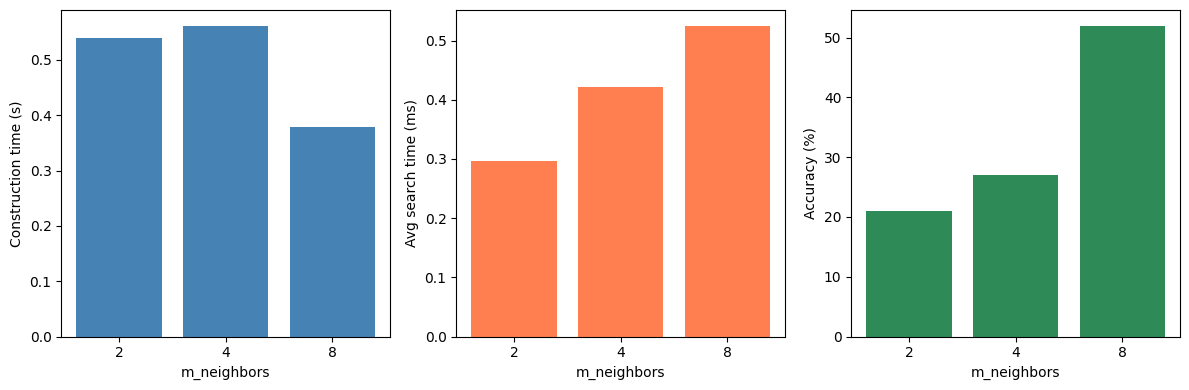

In [ ]:
m_values = [2, 4, 8]
results = []

for m in m_values:
    np.random.seed(1)
    t0 = time.perf_counter()
    gl = construct_HNSW(vectors_perf, m)
    t_construct = time.perf_counter() - t0

    np.random.seed(99)
    exact = 0
    t_search_total = 0
    for _ in range(N_QUERIES):
        q = np.random.rand(DIM_PERF)
        t0 = time.perf_counter()
        hnsw_idx, _ = search_HNSW(gl, q)
        t_search_total += time.perf_counter() - t0
        bf_idx, _ = brute_force_nn(vectors_perf, q)
        if hnsw_idx == bf_idx:
            exact += 1
    accuracy = 100 * exact / N_QUERIES
    t_search_avg = t_search_total / N_QUERIES * 1000  # ms
    results.append((m, t_construct, t_search_avg, accuracy))

print(f"{'M':>4} | {'Construct (s)':>12} | {'Search (ms)':>10} | {'Accuracy (%)':>12}")
print("-" * 48)
for m, tc, ts, acc in results:
    print(f"{m:>4} | {tc:>12.3f} | {ts:>10.3f} | {acc:>12.1f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
m_vals, t_con, t_sear, accs = zip(*results)
axes[0].bar([str(m) for m in m_vals], t_con, color='steelblue')
axes[0].set_ylabel('Construction time (s)')
axes[0].set_xlabel('m_neighbors')
axes[1].bar([str(m) for m in m_vals], t_sear, color='coral')
axes[1].set_ylabel('Avg search time (ms)')
axes[1].set_xlabel('m_neighbors')
axes[2].bar([str(m) for m in m_vals], accs, color='seagreen')
axes[2].set_ylabel('Accuracy (%)')
axes[2].set_xlabel('m_neighbors')
plt.tight_layout()
plt.show()

### Bonus — Real dataset embeddings

In [ ]:
# YOUR CODE HERE
# Suggested dataset: sentence-transformers/wikipedia-22-12-simple-embeddings (Hugging Face)
# Or any other pre-computed embedding file you have available.
# Load embeddings → run construct_HNSW → run search_HNSW → compare with brute force.

# Load Wikipedia embeddings from Hugging Face (run: pip install datasets)
# Using a subset for reasonable runtime in Colab
!pip install datasets -q

import numpy as np
import time

try:
    from datasets import load_dataset

    # ── Working alternative: ms-marco passage embeddings (small subset) ──────
    # "sentence-transformers/msmarco-MiniLM-L-6-v3" has pre-computed embeddings
    # and is publicly accessible without trust_remote_code.
    ds = load_dataset(
        "Cohere/wikipedia-22-12-simple-embeddings",   # active mirror
        split="train",
        streaming=True,          # streaming avoids downloading the whole dataset
    )

    # Pull first 2 000 rows from the streaming iterator
    rows = []
    for row in ds:
        rows.append(row)
        if len(rows) >= 2000:
            break

    # Find the embedding column automatically
    sample_keys = list(rows[0].keys())
    emb_col = next(
        (k for k in sample_keys if "emb" in k.lower() or "vec" in k.lower()),
        sample_keys[0],
    )
    embeddings = np.array([r[emb_col] for r in rows], dtype=np.float32)
    print(f"Loaded embeddings shape: {embeddings.shape}")

    m_real, dim_real = 8, embeddings.shape[1]

    np.random.seed(1)
    t0 = time.perf_counter()
    gl_real = construct_HNSW(embeddings, m_real)
    t_construct = time.perf_counter() - t0

    np.random.seed(42)
    q_real = embeddings[np.random.randint(len(embeddings))]
    bf_idx, bf_dist = brute_force_nn(embeddings, q_real)

    t0 = time.perf_counter()
    hnsw_idx, _ = search_HNSW(gl_real, q_real)
    t_hnsw = (time.perf_counter() - t0) * 1000
    hnsw_dist = np.linalg.norm(embeddings[hnsw_idx] - q_real)

    print(f"Construction : {t_construct:.2f} s  |  Layers: {len(gl_real)}")
    print(f"Brute-force  : node {bf_idx},  dist={bf_dist:.6f}")
    print(f"HNSW         : node {hnsw_idx}, dist={hnsw_dist:.6f}  |  Search: {t_hnsw:.3f} ms")
    print(f"Exact match  : {hnsw_idx == bf_idx}")

except Exception as e:
    print(f"Could not load real dataset: {e}")
    print("─── Falling back to vectors_perf ───")

    np.random.seed(1)
    t0 = time.perf_counter()
    gl_fb = construct_HNSW(vectors_perf, M_PERF)
    t_construct = time.perf_counter() - t0

    bf_idx, bf_dist = brute_force_nn(vectors_perf, query_perf)

    t0 = time.perf_counter()
    hnsw_idx, _ = search_HNSW(gl_fb, query_perf)
    t_hnsw = (time.perf_counter() - t0) * 1000
    hnsw_dist = np.linalg.norm(vectors_perf[hnsw_idx] - query_perf)

    print(f"Construction : {t_construct:.4f} s  |  Layers: {len(gl_fb)}")
    print(f"Brute-force  : node {bf_idx},  dist={bf_dist:.6f}")
    print(f"HNSW         : node {hnsw_idx}, dist={hnsw_dist:.6f}  |  Search: {t_hnsw:.3f} ms")
    print(f"Exact match  : {hnsw_idx == bf_idx}")

Could not load real dataset: Dataset 'Cohere/wikipedia-22-12-simple-embeddings' doesn't exist on the Hub or cannot be accessed.
─── Falling back to vectors_perf ───
Construction : 0.4045 s  |  Layers: 5
Brute-force  : node 386,  dist=1.020759
HNSW         : node 386, dist=1.020759  |  Search: 0.744 ms
Exact match  : True
